Pulling Elexon Physical PN data from 2026-05-14 to 2026-06-12
Raw rows: 3760506
  dataset settlementDate  settlementPeriod              timeFrom  \
0      PN     2026-05-14                 1  2026-05-13T23:29:00Z   
1      PN     2026-05-14                 1  2026-05-13T23:29:00Z   
2      PN     2026-05-14                 1  2026-05-13T23:29:00Z   
3      PN     2026-05-14                 1  2026-05-13T23:29:00Z   
4      PN     2026-05-14                 1  2026-05-13T23:29:00Z   

                 timeTo  levelFrom  levelTo nationalGridBmUnit       bmUnit  
0  2026-05-13T23:30:00Z         36        0             BFSE03  2__BCMRO002  
1  2026-05-13T23:30:00Z          9        0             FFSE02  2__FCMRO003  
2  2026-05-13T23:30:00Z         13        0          AG-GFLX08  2__GFLEX008  
3  2026-05-13T23:30:00Z         15        0          AG-NFLX01  2__NFLEX001  
4  2026-05-13T23:30:00Z         14       15            BEATO-1    T_BEATO-1  
Index(['dataset', 'settlementDate', 'settle

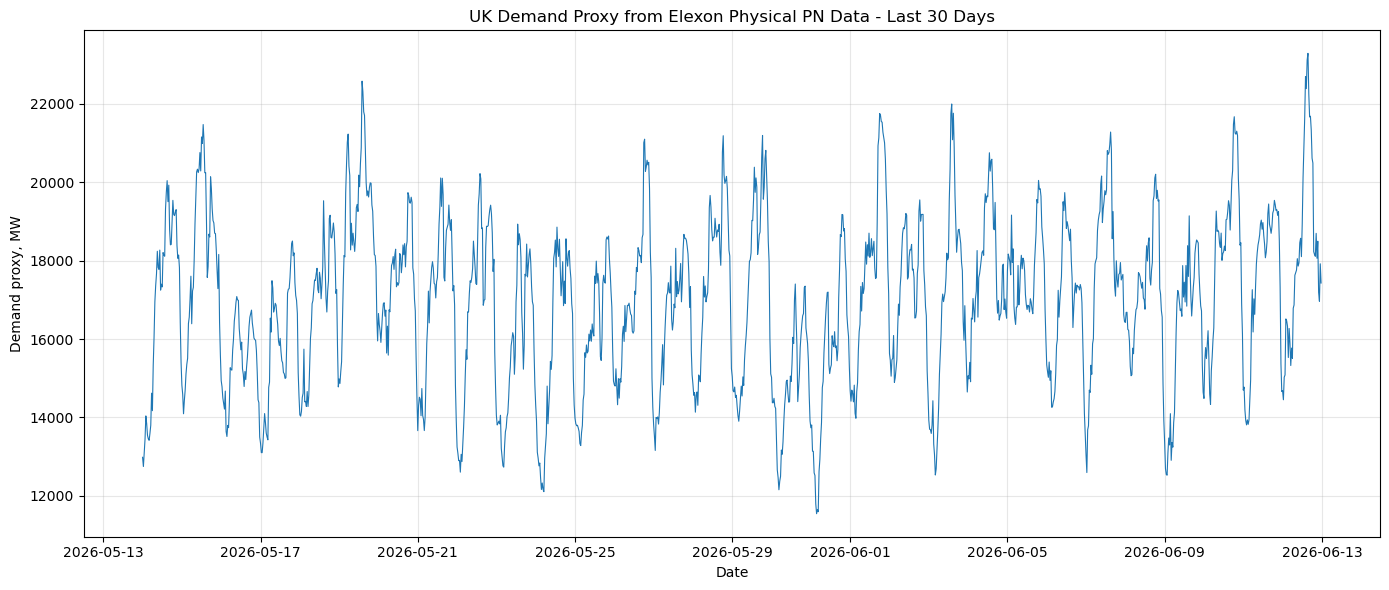

Saved graph to: uk_demand_last_month_half_hourly.png


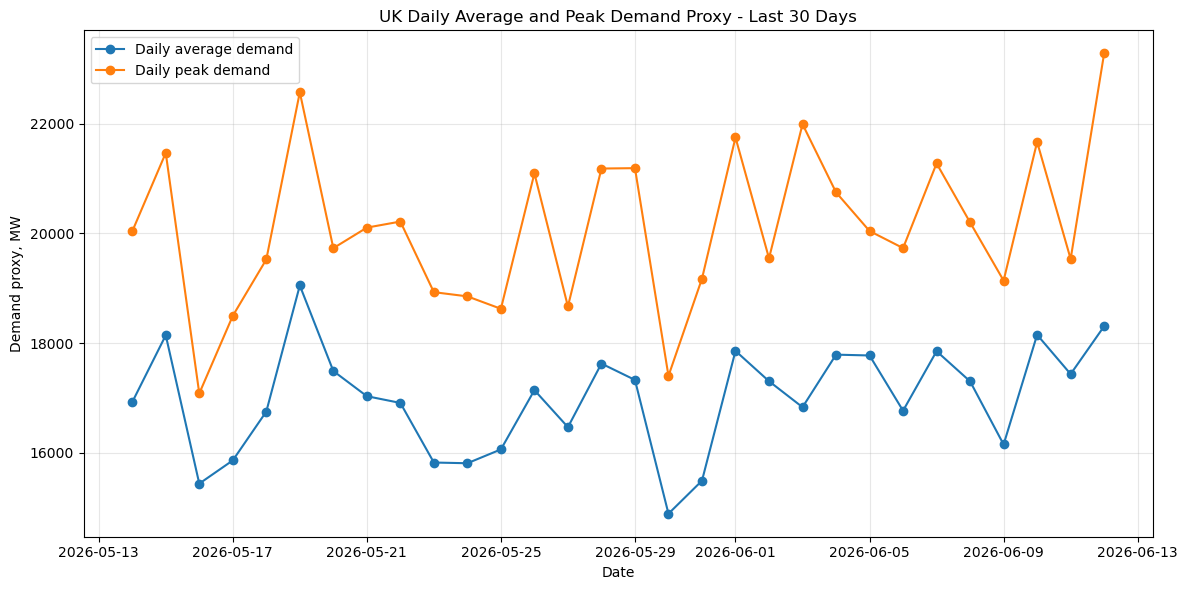

Saved graph to: uk_demand_last_month_daily.png


In [3]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from pathlib import Path


BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1"


def extract_records(payload):
    """
    Elexon usually returns {"data": [...]}, but this keeps it robust.
    """
    if isinstance(payload, list):
        return payload

    if isinstance(payload, dict):
        for key in ["data", "items", "results"]:
            if key in payload and isinstance(payload[key], list):
                return payload[key]

    return []


def fetch_physical_pn_for_period(settlement_date, settlement_period, bm_units=None, max_retries=5):
    """
    Pull PN data for one settlement date and settlement period.

    This endpoint returns market-wide PN if bm_units=None.
    """

    url = f"{BASE_URL}/balancing/physical/all"

    params = {
        "dataset": "PN",
        "settlementDate": settlement_date,
        "settlementPeriod": settlement_period,
        "format": "json",
    }

    if bm_units:
        params["bmUnit"] = bm_units

    for attempt in range(max_retries):
        response = requests.get(url, params=params, timeout=60)

        # Some settlement periods may not exist on normal days.
        if response.status_code in [400, 404]:
            return pd.DataFrame()

        # Rate limit handling
        if response.status_code == 429:
            wait = 5 * (attempt + 1)
            print(f"Rate limited. Waiting {wait} seconds...")
            time.sleep(wait)
            continue

        response.raise_for_status()

        payload = response.json()
        records = extract_records(payload)

        return pd.DataFrame(records)

    raise RuntimeError(f"Failed after {max_retries} retries: {settlement_date} SP{settlement_period}")


def get_elexon_physical_pn_range(start_date, end_date, bm_units=None, sleep_seconds=0.20):
    """
    Pull PN data for every settlement period between start_date and end_date inclusive.
    """

    start = datetime.strptime(start_date, "%Y-%m-%d").date()
    end = datetime.strptime(end_date, "%Y-%m-%d").date()

    all_frames = []
    current = start

    while current <= end:
        settlement_date = current.isoformat()
        print(f"Downloading {settlement_date}")

        # Settlement periods are usually 1-48.
        # Use 1-50 to handle clock-change days.
        for sp in range(1, 51):
            df_sp = fetch_physical_pn_for_period(
                settlement_date=settlement_date,
                settlement_period=sp,
                bm_units=bm_units,
            )

            if not df_sp.empty:
                all_frames.append(df_sp)

            time.sleep(sleep_seconds)

        current += timedelta(days=1)

    if not all_frames:
        return pd.DataFrame()

    return pd.concat(all_frames, ignore_index=True)


def clean_physical_pn_to_demand(raw_df):
    """
    Convert BMU-level PN values into a demand-like series.

    Logic:
    - Positive PN = export/generation.
    - Negative PN = import/demand.
    - Demand proxy = max(-PN, 0).
    """

    df = raw_df.copy()

    df.columns = [c.strip() for c in df.columns]

    required_cols = [
        "settlementDate",
        "settlementPeriod",
        "levelFrom",
        "levelTo",
    ]

    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        print("Columns returned by API:")
        print(df.columns.tolist())
        raise ValueError(f"Missing expected columns: {missing}")

    df["settlementDate"] = pd.to_datetime(df["settlementDate"]).dt.date

    df["settlementPeriod"] = pd.to_numeric(
        df["settlementPeriod"],
        errors="coerce"
    ).astype("Int64")

    df["levelFrom"] = pd.to_numeric(df["levelFrom"], errors="coerce")
    df["levelTo"] = pd.to_numeric(df["levelTo"], errors="coerce")

    # Use midpoint of levelFrom and levelTo as MW value
    df["pn_mw"] = df[["levelFrom", "levelTo"]].mean(axis=1)

    # Convert negative PN/import into positive demand
    df["demand_like_mw"] = (-df["pn_mw"]).clip(lower=0)

    # Half-hour timestamp
    df["period_start_local"] = (
        pd.to_datetime(df["settlementDate"].astype(str))
        + pd.to_timedelta((df["settlementPeriod"] - 1) * 30, unit="min")
    )

    keep_cols = [
        "settlementDate",
        "settlementPeriod",
        "period_start_local",
        "bmUnit",
        "nationalGridBmUnit",
        "timeFrom",
        "timeTo",
        "levelFrom",
        "levelTo",
        "pn_mw",
        "demand_like_mw",
    ]

    keep_cols = [c for c in keep_cols if c in df.columns]

    return (
        df[keep_cols]
        .sort_values(["settlementDate", "settlementPeriod"])
        .reset_index(drop=True)
    )


def aggregate_demand_by_settlement_period(clean_df):
    """
    Aggregate BMU-level PN import values into one demand-like value per settlement period.
    """

    demand_sp = (
        clean_df
        .groupby(
            ["settlementDate", "settlementPeriod", "period_start_local"],
            as_index=False
        )
        .agg(
            physical_pn_demand_mw=("demand_like_mw", "sum"),
            importing_bmu_count=("demand_like_mw", lambda x: (x > 0).sum()),
            total_bmu_count=("demand_like_mw", "size"),
        )
        .sort_values(["settlementDate", "settlementPeriod"])
        .reset_index(drop=True)
    )

    return demand_sp


def plot_last_month_demand(demand_by_sp, output_png="uk_demand_last_month.png"):
    """
    Plot half-hourly PN-based UK demand proxy.
    """

    df = demand_by_sp.copy()

    df["period_start_local"] = pd.to_datetime(df["period_start_local"])

    plt.figure(figsize=(14, 6))

    plt.plot(
        df["period_start_local"],
        df["physical_pn_demand_mw"],
        linewidth=0.8
    )

    plt.title("UK Demand Proxy from Elexon Physical PN Data - Last 30 Days")
    plt.xlabel("Date")
    plt.ylabel("Demand proxy, MW")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(output_png, dpi=300)
    plt.show()

    print(f"Saved graph to: {output_png}")


def plot_daily_average_demand(demand_by_sp, output_png="uk_daily_average_demand_last_month.png"):
    """
    Plot daily average demand, which is easier to read than 30 days of half-hourly data.
    """

    df = demand_by_sp.copy()

    df["period_start_local"] = pd.to_datetime(df["period_start_local"])
    df["date"] = df["period_start_local"].dt.date

    daily = (
        df
        .groupby("date", as_index=False)
        .agg(
            daily_average_demand_mw=("physical_pn_demand_mw", "mean"),
            daily_peak_demand_mw=("physical_pn_demand_mw", "max"),
        )
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        daily["date"],
        daily["daily_average_demand_mw"],
        marker="o",
        label="Daily average demand"
    )

    plt.plot(
        daily["date"],
        daily["daily_peak_demand_mw"],
        marker="o",
        label="Daily peak demand"
    )

    plt.title("UK Daily Average and Peak Demand Proxy - Last 30 Days")
    plt.xlabel("Date")
    plt.ylabel("Demand proxy, MW")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_png, dpi=300)
    plt.show()

    print(f"Saved graph to: {output_png}")


# ============================================================
# Run: last 30 days
# ============================================================

today = datetime.today().date()
start = today - timedelta(days=30)
end = today - timedelta(days=1)

start_date = start.isoformat()
end_date = end.isoformat()

print(f"Pulling Elexon Physical PN data from {start_date} to {end_date}")

raw_file = Path("elexon_physical_pn_last_30_days_raw.csv")
clean_file = Path("elexon_physical_pn_last_30_days_bmu_level.csv")
demand_file = Path("elexon_physical_pn_demand_last_30_days.csv")

# Use cache if already downloaded, because this API call is quite heavy.
if raw_file.exists():
    print("Loading cached raw data...")
    raw_pn = pd.read_csv(raw_file)
else:
    raw_pn = get_elexon_physical_pn_range(
        start_date=start_date,
        end_date=end_date,
        bm_units=None,
        sleep_seconds=0.20,
    )

    raw_pn.to_csv(raw_file, index=False)

print("Raw rows:", len(raw_pn))
print(raw_pn.head())
print(raw_pn.columns)

clean_pn = clean_physical_pn_to_demand(raw_pn)
demand_by_sp = aggregate_demand_by_settlement_period(clean_pn)

clean_pn.to_csv(clean_file, index=False)
demand_by_sp.to_csv(demand_file, index=False)

print("\nAggregated demand data:")
print(demand_by_sp.head())

plot_last_month_demand(
    demand_by_sp,
    output_png="uk_demand_last_month_half_hourly.png"
)

plot_daily_average_demand(
    demand_by_sp,
    output_png="uk_demand_last_month_daily.png"
)